In [1]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
# Plot Styling
plt.style.use('dark_background')
plt.rcParams.update({
    'font.family':'serif', 'mathtext.fontset':'dejavuserif',
    'axes.grid':True, 'grid.linestyle': ':', 'grid.alpha': 0.5,
    'xtick.direction':'in', 'xtick.minor.visible': True, 'xtick.top':True,
    'ytick.direction':'in', 'ytick.minor.visible': True, 'ytick.right':True,
})

import sys
sys.path.insert(0, "/global/u2/c/cpopik/CAPPIBARAS")

import importlib
import numpy as np

from Models.PlotChecks.Hadzhiyska2025B import Hadzhiyska2025B

In [4]:
importlib.reload(Hadzhiyska2025B)

Hadzhiyska2025B.Table1_2_3().df

,Sample,Bin,logMcut,logM1,sigmalogM,alpha,kappa,nbar1000,fsat,logMhmean
0,MainLRGs,all,12.683,14.063,0.133,0.848,1.245,0.745,0.080,13.179
1,ExtendedLRGs,all,12.491,14.196,0.108,0.642,0.941,1.254,0.098,13.025
2,BGSlogM>10.5,all,12.133,13.830,0.107,1.219,1.069,3.608,0.108,13.022
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,MainLRGs,z1,12.610,13.910,0.300,1.000,1.300,1.300,0.080,13.190
5,MainLRGs,z2,12.630,14.020,0.180,0.840,1.300,1.090,0.090,13.220
6,MainLRGs,z3,12.730,13.980,0.210,0.960,1.330,0.690,0.080,13.200
7,MainLRGs,z4,12.630,13.970,0.230,0.960,1.280,0.910,0.070,13.120
8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,ExtendedLRGs,z1,12.490,13.960,0.240,0.920,1.280,1.580,0.070,13.110


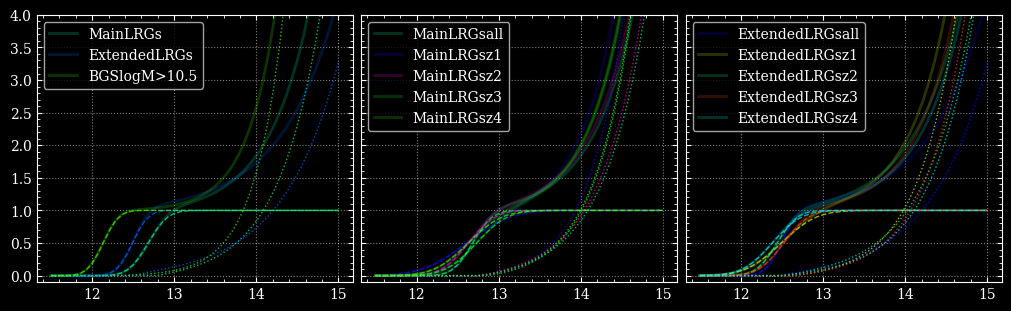

In [17]:
importlib.reload(Hadzhiyska2025B)
logMs = np.linspace(11.5, 15, 50)

fig, axs = plt.subplots(1, 3, figsize=(10, 3), sharex=True, sharey=True, layout='constrained')

for samp in ['MainLRGs', 'ExtendedLRGs', 'BGSlogM>10.5']:
    color = plt.get_cmap('hsv')(np.random.rand())
    model = Hadzhiyska2025B.HOD(logM=logMs, Sample=samp, Bin='all')
    axs[0].plot(logMs, model.Ncen()+model.Nsat(), alpha=0.2, lw=2, label=samp, color=color)
    axs[0].plot(logMs, model.Ncen(), alpha=0.7, ls='--', lw=1, color=color)
    axs[0].plot(logMs, model.Nsat(), alpha=0.7, ls=':', lw=1, color=color)

for ax, samp in zip(axs[1:], ['MainLRGs', 'ExtendedLRGs']):
    for bin in ['all', 'z1', 'z2', 'z3', 'z4']:
        color = plt.get_cmap('hsv')(np.random.rand())
        model = Hadzhiyska2025B.HOD(logM=logMs, Sample=samp, Bin=bin)
        ax.plot(logMs, model.Ncen()+model.Nsat(), alpha=0.2, lw=2, color=color, label=samp+bin)
        ax.plot(logMs, model.Ncen(), alpha=0.7, ls='--', lw=1, color=color)
        ax.plot(logMs, model.Nsat(), alpha=0.7, ls=':', lw=1, color=color)
        
for ax in axs:
    ax.legend()
    ax.set(ylim=(-0.1, 4))
    
plt.show()